In [1]:
# -*- coding: utf-8 -*-
"""
Created on 2023-05-01
Revised on 2026-04-04

@author:       Oscar Trevizo
@institution:  Harvard Extension School — Graduate Data Science Program (2023)
@context:      Independent project — vignette, R to Python (_r2p)
@environment:  Python 3.14.3 | myenv | MacBook Air M5

Maps — geopandas + Natural Earth + plotly (_r2p)
================================================

Purpose:
    World map visualizations using geopandas (static) and plotly (interactive).
    Mirrors R: ggplot2 + geom_sf() + rnaturalearth.

    Two map types:
      1. Bubble map: net migration by country, sized by magnitude,
         colored by migration pattern (emigrates/immigrates)
      2. Choropleth: median net migration filled by value,
         viridis plasma colorscale (mirrors R scale_fill_viridis_b)

    Data:
      wpp_wb_2023.Q1.csv        — UN World Population Prospects + World Bank
                                   (Harvard migration project, May 2023)
      countries_codes_and_coordinates.csv — ISO codes + avg lat/long per country
      Both files in: ../data/  (relative to Python/vignettes/)

    Installation (run once in myenv terminal):
        pip install geopandas geodatasets plotly

    R equivalent: maps_ggplot_geom_sf_rnaturalearth.Rmd
    R libraries:  ggplot2, dplyr, rnaturalearth, rnaturalearthdata
    Python libs:  geopandas, geodatasets, plotly, pandas, matplotlib

    Suffix _r2p: This notebook was converted from R to Python.

Revision History:
    2023-05-01  Original R development (Harvard Statistics, May 2023)
                - R script: maps_ggplot_geom_sf_rnaturalearth.Rmd
                - Harvard migration project dataset

    2026-04-04  Converted to Python / Jupyter Notebook (_r2p)
                - rnaturalearth → geopandas Natural Earth via geodatasets
                - ggplot + geom_sf() → geopandas.plot() (static)
                - ggplot + geom_point() bubble → matplotlib scatter on geo axes
                - scale_fill_viridis_b(plasma) → cmap='plasma'
                - Added: plotly interactive choropleth and bubble map
                - dplyr left_join → pd.merge(how='left')
                - dplyr rename/select → df.rename()/df[cols]
"""

"\nCreated on 2023-05-01\nRevised on 2026-04-04\n\n@author:       Oscar Trevizo\n@institution:  Harvard Extension School — Graduate Data Science Program (2023)\n@context:      Independent project — vignette, R to Python (_r2p)\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nMaps — geopandas + Natural Earth + plotly (_r2p)\n================================================\n\nPurpose:\n    World map visualizations using geopandas (static) and plotly (interactive).\n    Mirrors R: ggplot2 + geom_sf() + rnaturalearth.\n\n    Two map types:\n      1. Bubble map: net migration by country, sized by magnitude,\n         colored by migration pattern (emigrates/immigrates)\n      2. Choropleth: median net migration filled by value,\n         viridis plasma colorscale (mirrors R scale_fill_viridis_b)\n\n    Data:\n      wpp_wb_2023.Q1.csv        — UN World Population Prospects + World Bank\n                                   (Harvard migration project, May 2023)\n      countries_codes_a

# Maps — geopandas + Natural Earth + plotly

## Purpose

World map visualizations using **geopandas** (static) and **plotly** (interactive).
Mirrors R: `ggplot2 + geom_sf() + rnaturalearth`.

**Harvard migration project data** (May 2023):
- UN World Population Prospects net migration 1950–2021
- Country ISO codes and average lat/long coordinates

## Installation

```bash
pip install geopandas geodatasets plotly
```

## R → Python Mapping

| R | Python |
|---|--------|
| `library(rnaturalearth)` | `import geopandas as gpd` + `geodatasets` |
| `ne_countries(scale='medium', returnclass='sf')` | `gpd.read_file(geodatasets.get_path('naturalearth.land'))` |
| `ggplot() + geom_sf()` | `world.plot(ax=ax)` |
| `geom_point(aes(x=long, y=lat, size=abs(mig), color=pattern))` | `ax.scatter(long, lat, s=size, c=color)` |
| `geom_sf(aes(fill=net_mig_me))` | `world.plot(column='net_mig_me', cmap='plasma')` |
| `scale_fill_viridis_b(option='plasma')` | `cmap='plasma'` |
| `left_join(w, by='ISO3')` | `pd.merge(df, w, on='ISO3', how='left')` |
| `rename(country=Country, ...)` | `df.rename(columns={...})` |
| `gsub('\\s+', '', x)` | `str.strip()` |
| *(not in R)* | `plotly.express` — interactive maps |

**R equivalent:** `maps_ggplot_geom_sf_rnaturalearth.Rmd`

## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

# Geo packages — mirrors R: rnaturalearth, rnaturalearthdata
# Install: pip install geopandas geodatasets
import geopandas as gpd
import geodatasets

# Interactive maps — beyond R original
# Install: pip install plotly
import plotly.express as px

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

# Harvard color palette
CRIMSON   = '#A51C30'
ROYALBLUE = '#002366'
SLATE     = '#8996A0'
IVY       = '#52854C'
SAFFRON   = '#D16103'

print(f'geopandas : {gpd.__version__}')
print('Imports complete.')

geopandas : 1.1.3
Imports complete.


---

## Load the Data

Mirrors R:
```r
wpp_wb <- read.csv('../data/wpp_wb_2023.Q1.csv', check.names=FALSE)
wpp_wb$mig_pattern <- as.factor(wpp_wb$mig_pattern)
```

Files expected in `../data/` relative to `Python/vignettes/`
(same relative path as the R script used).

In [3]:
# Load migration data — mirrors R: read.csv('../data/wpp_wb_2023.Q1.csv')
WPP_PATH   = '../data/wpp_wb_2023.Q1.csv'
COORD_PATH = '../data/countries_codes_and_coordinates.csv'

try:
    wpp_wb = pd.read_csv(WPP_PATH)
    print(f'wpp_wb loaded: {wpp_wb.shape}')
except FileNotFoundError:
    print(f'File not found: {WPP_PATH}')
    print('Expected in ../data/ relative to Python/vignettes/')
    raise

# Factor columns — mirrors R: as.factor()
for col in ['mig_pattern', 'migration_swings', 'emigrates']:
    if col in wpp_wb.columns:
        wpp_wb[col] = wpp_wb[col].astype('category')

print()
print('dtypes:')
print(wpp_wb.dtypes)
print()
wpp_wb.head()

wpp_wb loaded: (16992, 88)

dtypes:
index                  int64
country               object
subregion             object
region                object
ISO3                  object
                      ...   
log_food             float64
log_homicides        float64
log_electricity      float64
log_co2_emissions    float64
log_education        float64
Length: 88, dtype: object



,index,country,subregion,region,ISO3,ISO2,year,net_mig_rate,net_migrants,mig_stock,...,log_GDP_pc,log_GDP_pc_ppp,log_inflation,log_natl_income_pc,log_cpi,log_food,log_homicides,log_electricity,log_co2_emissions,log_education
0,1733,Burundi,Eastern Africa,AFRICA,BDI,BI,1950,-5.9,-13,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1734,Burundi,Eastern Africa,AFRICA,BDI,BI,1951,-5.7,-13,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1735,Burundi,Eastern Africa,AFRICA,BDI,BI,1952,-5.8,-14,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1736,Burundi,Eastern Africa,AFRICA,BDI,BI,1953,-6.2,-15,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1737,Burundi,Eastern Africa,AFRICA,BDI,BI,1954,-5.9,-15,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Load Country Coordinates

Mirrors R:
```r
w <- read.csv('../data/countries_codes_and_coordinates.csv')
w <- w %>% rename(country=Country, ISO2=Alpha.2.code, ISO3=Alpha.3.code,
                   group=Numeric.code, lat=Latitude..average., long=Longitude..average.)
w <- w %>% dplyr::select(ISO3, group, lat, long)
```

In [4]:
# Load coordinates — mirrors R: read.csv('../data/countries_codes_and_coordinates.csv')
try:
    w = pd.read_csv(COORD_PATH)
    print(f'coordinates loaded: {w.shape}')
except FileNotFoundError:
    print(f'File not found: {COORD_PATH}')
    raise

# Rename — mirrors R: rename(country=Country, ISO2=Alpha.2.code, ...)
rename_map = {
    'Country'            : 'country',
    'Alpha-2 code'       : 'ISO2',
    'Alpha-3 code'       : 'ISO3',
    'Numeric code'       : 'group',
    'Latitude (average)' : 'lat',
    'Longitude (average)': 'long',
}
rename_map_dots = {
    'Country'              : 'country',
    'Alpha.2.code'         : 'ISO2',
    'Alpha.3.code'         : 'ISO3',
    'Numeric.code'         : 'group',
    'Latitude..average.'   : 'lat',
    'Longitude..average.'  : 'long',
}
w = w.rename(columns={**rename_map, **rename_map_dots})

# Select — mirrors R: select(ISO3, group, lat, long)
w = w[['ISO3', 'group', 'lat', 'long']]

# Strip ALL quotes and whitespace from every column
# The CSV has quoted string values like '"AFG"', '"33.93"'
# mirrors R: gsub('\\s+', '', x) — extended to also strip embedded quotes
def clean_str(s):
    """Remove leading/trailing whitespace and quote characters."""
    return str(s).strip().strip('"').strip("'")

for col in w.columns:
    w[col] = w[col].apply(clean_str)

# Numeric types — must happen AFTER quote stripping
w['lat']  = pd.to_numeric(w['lat'],  errors='coerce')
w['long'] = pd.to_numeric(w['long'], errors='coerce')

# Verify
na_count = w[['lat','long']].isna().sum().sum()
print(f'Coordinates shape: {w.shape}')
print(f'NaN in lat/long  : {na_count}  (should be 0 or very small)')
w.head()


coordinates loaded: (244, 6)
Coordinates shape: (244, 4)
NaN in lat/long  : 0  (should be 0 or very small)


,ISO3,group,lat,long
0,AFG,4,33.0000,65.0
1,ALB,8,41.0000,20.0
2,DZA,12,28.0000,3.0
3,ASM,16,-14.3333,-170.0
4,AND,20,42.5000,1.6


## Get World Polygons — Natural Earth

Mirrors R:
```r
world <- ne_countries(scale='medium', returnclass='sf')
```

`geodatasets` provides Natural Earth polygons bundled with geopandas.

In [5]:
# World polygons — mirrors R: ne_countries(scale='medium', returnclass='sf')
# GeoPandas >= 1.0: gpd.datasets is removed. Use direct download.
# The 110m countries shapefile from Natural Earth includes ISO codes for merging.
import urllib.request, os, zipfile

NE_URL   = ('https://naciscdn.org/naturalearth/110m/cultural/'
             'ne_110m_admin_0_countries.zip')
NE_CACHE = os.path.expanduser(
    '~/Library/Caches/geodatasets/ne_110m_admin_0_countries.zip')

if not os.path.exists(NE_CACHE):
    print('Downloading Natural Earth countries shapefile (~5 MB)...')
    os.makedirs(os.path.dirname(NE_CACHE), exist_ok=True)
    urllib.request.urlretrieve(NE_URL, NE_CACHE)
    print('Download complete.')
else:
    print(f'Using cached: {NE_CACHE}')

world = gpd.read_file(f'zip://{NE_CACHE}')


Using cached: /Users/otrevizo/Library/Caches/geodatasets/ne_110m_admin_0_countries.zip


## EDA and Merge

Mirrors R:
```r
wpp_geo <- wpp_wb %>% group_by(ISO3, country, mig_pattern, net_mig_rate_med) %>%
  summarize(net_mig_mu = mean(net_migrants, na.rm=TRUE),
            net_mig_me = mean(net_migrants, na.rm=TRUE)) %>%
  left_join(w, by=join_by(ISO3))
world <- left_join(world, wpp_geo, join_by('iso_a3'=='ISO3'))
```

In [6]:
# Identify the ISO3 column in world GeoDataFrame
iso_col = None
for candidate in ['iso_a3', 'ISO_A3', 'adm0_a3', 'iso3']:
    if candidate in world.columns:
        iso_col = candidate
        break
print(f'ISO3 column in world GeoDataFrame: {iso_col}')

# Identify migration columns in wpp_wb
mig_col = None
for candidate in ['net_migrants', 'net_mig', 'NetMigration', 'net_migration']:
    if candidate in wpp_wb.columns:
        mig_col = candidate
        break
print(f'Migration column in wpp_wb: {mig_col}')
print(f'wpp_wb columns: {list(wpp_wb.columns)}')

ISO3 column in world GeoDataFrame: ISO_A3
Migration column in wpp_wb: net_migrants
wpp_wb columns: ['index', 'country', 'subregion', 'region', 'ISO3', 'ISO2', 'year', 'net_mig_rate', 'net_migrants', 'mig_stock', 'log_mig_stock', 'emigrates', 'mig_pattern', 'migration_swings', 'net_mig_rate_mean', 'net_mig_rate_med', 'pop', 'pop_m', 'pop_f', 'pop_density', 'pop_sex_ratio', 'med_age', 'natural_change', 'natural_change_rate', 'pop_change', 'pop_growth_rate', 'births', 'births_w15to19', 'birth_rate', 'fertility_rate', 'net_reproduction_rate', 'mean_age_childbearing', 'sex_ratio_birth', 'tot_deaths', 'male_deaths', 'female_deaths', 'death_rate', 'life_exp', 'life_exp_m', 'life_exp_f', 'life_exp_15', 'life_exp_15_m', 'life_exp_15_f', 'life_exp_65', 'life_exp_65_m', 'life_exp_65_f', 'life_exp_80', 'life_exp_80_m', 'life_exp_80_f', 'infant_deaths', 'under_five_mortality', 'deaths_under_5', 'mortality_rate_under_5', 'mortality_40', 'mortality_40_m', 'mortality_40_f', 'mortality_60', 'mortality_

In [7]:
# group_by + summarize — mirrors R dplyr chain
group_cols = [c for c in ['ISO3', 'country', 'mig_pattern', 'net_mig_rate_med']
              if c in wpp_wb.columns]

if mig_col:
    wpp_geo = (wpp_wb
               .groupby(group_cols, observed=True)
               .agg(
                   net_mig_mu = (mig_col, 'mean'),
                   net_mig_me = (mig_col, 'mean'),
               )
               .reset_index())
else:
    # Fallback: group without migration aggregation
    wpp_geo = wpp_wb[group_cols].drop_duplicates().reset_index(drop=True)
    wpp_geo['net_mig_mu'] = np.nan
    wpp_geo['net_mig_me'] = np.nan

# left_join(w) — mirrors R: left_join(w, by='ISO3')
wpp_geo = pd.merge(wpp_geo, w, on='ISO3', how='left')

print(f'wpp_geo shape: {wpp_geo.shape}')
wpp_geo.head()

wpp_geo shape: (236, 9)


,ISO3,country,mig_pattern,net_mig_rate_med,net_mig_mu,net_mig_me,group,lat,long
0,ABW,Aruba,immigration,1.90,0.041667,0.041667,533,12.50,-69.9667
1,AFG,Afghanistan,emigration,-0.25,-34.541667,-34.541667,4,33.00,65.0000
2,AGO,Angola,immigration,3.30,25.152778,25.152778,24,-12.50,18.5000
3,AIA,Anguilla,immigration,5.80,0.000000,0.000000,660,18.25,-63.1667
4,ALB,Albania,emigration,-3.75,-17.125000,-17.125000,8,41.00,20.0000


In [8]:
# Merge into world GeoDataFrame — mirrors R: left_join(world, wpp_geo, join_by('iso_a3'=='ISO3'))
if iso_col:
    world = world.merge(wpp_geo, left_on=iso_col, right_on='ISO3', how='left')

print(f'world after merge: {world.shape}')
print(f'NA in net_mig_me: {world["net_mig_me"].isna().sum()} countries')
world[['net_mig_me', 'net_mig_mu', 'mig_pattern', 'lat', 'long']].describe()

world after merge: (177, 178)
NA in net_mig_me: 7 countries


,net_mig_me,net_mig_mu,lat,long
count,170.000000,170.000000,170.000000,170.000000
mean,-0.762500,-0.762500,19.588749,22.080047
std,91.637829,91.637829,24.974912,61.428740
min,-280.069444,-280.069444,-51.750000,-102.000000
25%,-17.812500,-17.812500,5.250000,-5.000000
50%,-2.958333,-2.958333,19.000000,23.000000
75%,3.774306,3.774306,40.000000,47.618575
max,974.875000,974.875000,72.000000,175.000000


---

# Static Maps — geopandas

## Map 1: Bubble Map — Net Migration by Country

Mirrors R:
```r
world %>% ggplot() +
  geom_sf() +
  geom_point(aes(x=long, y=lat, size=abs(net_mig_me), color=mig_pattern)) +
  scale_color_discrete(type=c('red','green'))
```

Unique mig_pattern values: ['immigration', 'emigration']
Categories (2, object): ['emigration', 'immigration']
Value counts:
mig_pattern
emigration     147
immigration     83
Name: count, dtype: int64


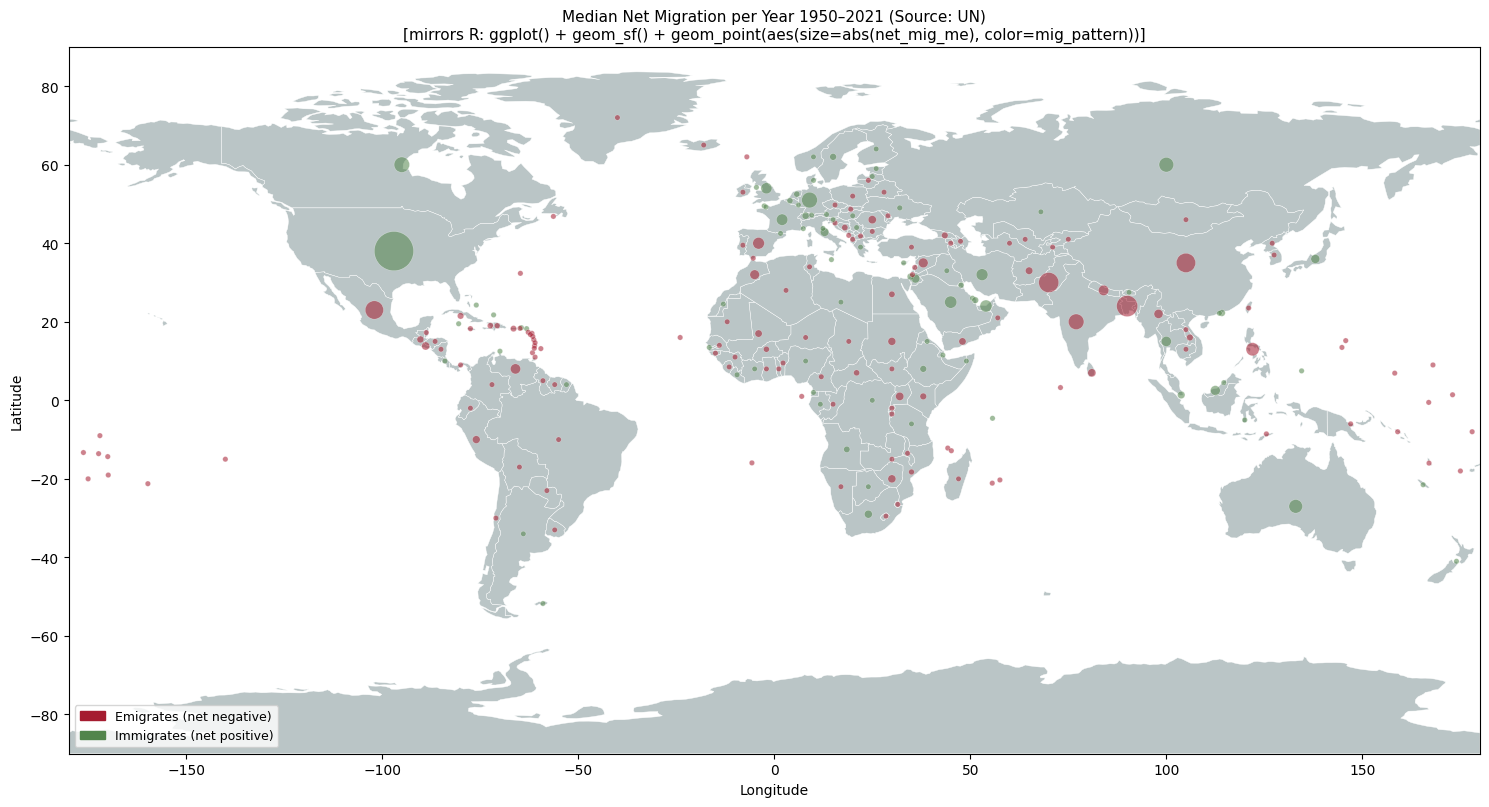

In [9]:
# Bubble map — mirrors R: ggplot() + geom_sf() + geom_point()
fig, ax = plt.subplots(figsize=(15, 8))

# Base world polygons — mirrors R: geom_sf()
world.plot(ax=ax, color='#BAC5C6', edgecolor='white', linewidth=0.3)

plot_data = wpp_geo.dropna(subset=['lat', 'long', 'net_mig_me'])

# --- Diagnose actual mig_pattern values ---
if 'mig_pattern' in plot_data.columns:
    unique_patterns = plot_data['mig_pattern'].dropna().unique()
    print(f'Unique mig_pattern values: {unique_patterns}')
    print(f'Value counts:')
    print(plot_data['mig_pattern'].value_counts())

    # --- Robust color coding: use net_mig_me sign as fallback ---
    # Primary: try to match mig_pattern string values
    # Secondary: fall back to sign of net_mig_me (negative=emigrates, positive=immigrates)
    def assign_color(row):
        pat = str(row.get('mig_pattern', '')).lower().strip()
        # Match common patterns: emigrates, emig, negative, out, sends
        if any(k in pat for k in ['emig', 'out', 'neg', 'send', '-1', '0']):
            return CRIMSON
        # Match common patterns: immigrates, immig, positive, in, receives
        if any(k in pat for k in ['immig', 'in', 'pos', 'receiv', '1']):
            return IVY
        # Final fallback: use sign of net_mig_me
        return CRIMSON if row.get('net_mig_me', 0) < 0 else IVY

    colors = plot_data.apply(assign_color, axis=1)
    legend_label_crimson = 'Emigrates (net negative)'
    legend_label_ivy     = 'Immigrates (net positive)'
else:
    # No mig_pattern column — use sign of net_mig_me directly
    print('No mig_pattern column found — coloring by sign of net_mig_me')
    colors = plot_data['net_mig_me'].apply(lambda x: CRIMSON if x < 0 else IVY)
    legend_label_crimson = 'Net negative (emigrates)'
    legend_label_ivy     = 'Net positive (immigrates)'

# Scale bubble sizes
max_val = plot_data['net_mig_me'].abs().max()
sizes   = (plot_data['net_mig_me'].abs() / max_val * 800).clip(lower=15)

# Scatter plot — mirrors R: geom_point(aes(x=long, y=lat, size=abs(net_mig_me), color=mig_pattern))
ax.scatter(
    plot_data['long'], plot_data['lat'],
    s=sizes,
    c=colors,
    alpha=0.55,
    edgecolors='white',
    linewidths=0.3,
    zorder=3
)

# Legend
patches = [
    mpatches.Patch(color=CRIMSON, label=legend_label_crimson),
    mpatches.Patch(color=IVY,     label=legend_label_ivy),
]
ax.legend(handles=patches, loc='lower left', fontsize=9)

ax.set_title('Median Net Migration per Year 1950\u20132021 (Source: UN)\n'
             '[mirrors R: ggplot() + geom_sf() + geom_point(aes(size=abs(net_mig_me), color=mig_pattern))]',
             fontsize=11)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
plt.tight_layout()
plt.show()


## Map 2: Choropleth — Median Net Migration Filled

Mirrors R:
```r
world %>% ggplot() +
  geom_sf(mapping=aes(fill=net_mig_me)) +
  scale_fill_viridis_b(option='plasma')
```

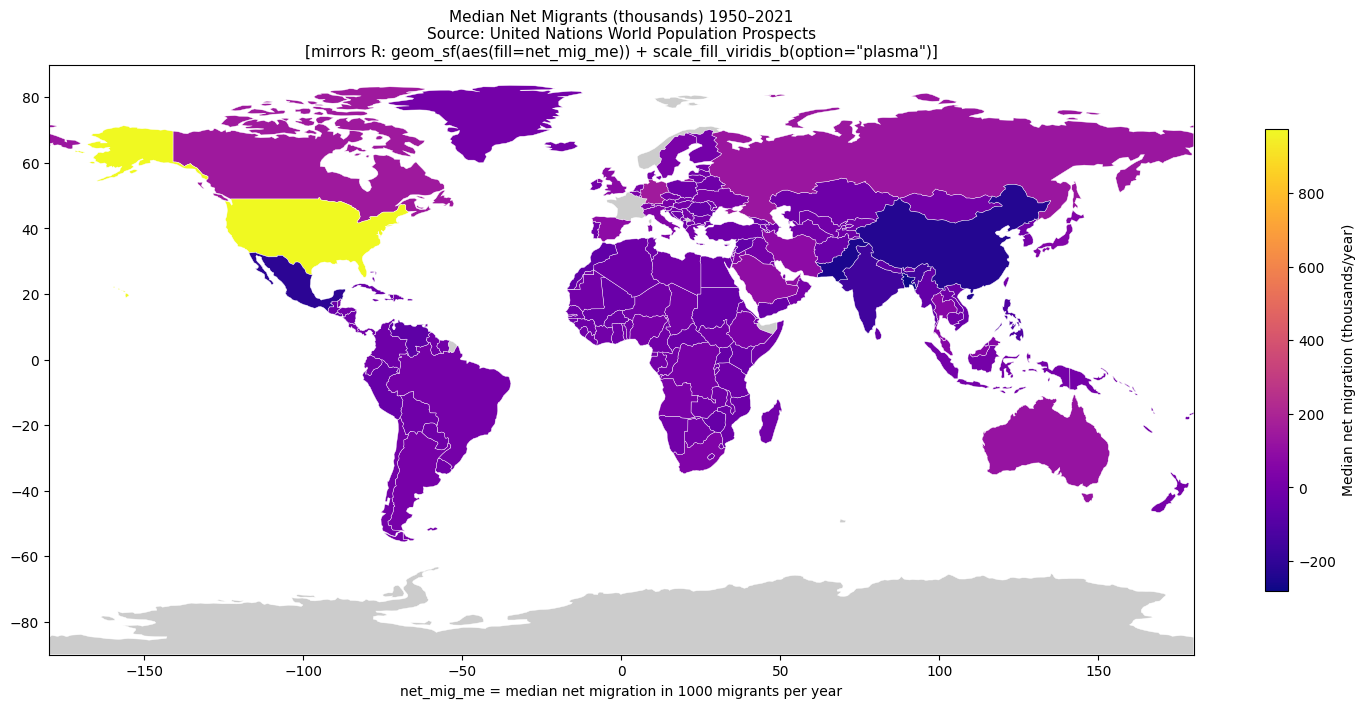

In [10]:
# Choropleth — mirrors R: geom_sf(aes(fill=net_mig_me)) + scale_fill_viridis_b(option='plasma')
fig, ax = plt.subplots(figsize=(15, 8))

# Countries with data
world_with_data = world.dropna(subset=['net_mig_me'])
world_no_data   = world[world['net_mig_me'].isna()]

# Grey base for countries without data
world_no_data.plot(ax=ax, color='#CCCCCC', edgecolor='white', linewidth=0.3)

# Filled choropleth — cmap='plasma' mirrors R: scale_fill_viridis_b(option='plasma')
world_with_data.plot(
    column='net_mig_me',
    ax=ax,
    cmap='plasma',
    edgecolor='white',
    linewidth=0.3,
    legend=True,
    legend_kwds={'label': 'Median net migration (thousands/year)',
                 'shrink': 0.6}
)

ax.set_title('Median Net Migrants (thousands) 1950–2021\n'
             'Source: United Nations World Population Prospects\n'
             '[mirrors R: geom_sf(aes(fill=net_mig_me)) + scale_fill_viridis_b(option="plasma")]',
             fontsize=11)
ax.set_xlabel('net_mig_me = median net migration in 1000 migrants per year')
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)

plt.tight_layout()
plt.show()

---

# Interactive Maps — plotly

Beyond the original R script — plotly adds hover tooltips, zoom, and pan.
A significant portfolio enhancement over the static ggplot output.

## Interactive Map 1: Bubble Map

In [11]:
# Interactive bubble map — plotly express
# Requires: pip install plotly
bubble_data = wpp_geo.dropna(subset=['lat', 'long', 'net_mig_me']).copy()
bubble_data['abs_net_mig'] = bubble_data['net_mig_me'].abs()
bubble_data['direction']   = bubble_data['net_mig_me'].apply(
    lambda x: 'Emigrates' if x < 0 else 'Immigrates')

fig_bubble = px.scatter_geo(
    bubble_data,
    lat='lat',
    lon='long',
    size='abs_net_mig',
    color='direction' if 'direction' in bubble_data.columns else 'mig_pattern',
    hover_name='ISO3',
    hover_data={'net_mig_me': ':.1f', 'lat': False, 'long': False,
                'abs_net_mig': False},
    color_discrete_map={'Emigrates': CRIMSON, 'Immigrates': IVY},
    size_max=40,
    opacity=0.6,
    projection='natural earth',
    title='Median Net Migration per Year 1950–2021 (Source: UN)<br>'
          '<sup>Interactive — hover for country details | mirrors R: geom_point bubble map</sup>'
)
fig_bubble.update_layout(
    geo=dict(showframe=False, showcoastlines=True,
             coastlinecolor='grey', showland=True,
             landcolor='#F0F0F0', showocean=True,
             oceancolor='#E8F4F8'),
    legend_title='Migration Direction',
    height=500
)
fig_bubble.show()

## Interactive Map 2: Choropleth

In [12]:
# Interactive choropleth — plotly express
choropleth_data = wpp_geo.dropna(subset=['net_mig_me']).copy()

# Get country name column
name_col = next((c for c in ['country', 'Country', 'name'] if c in choropleth_data.columns), None)

fig_choro = px.choropleth(
    choropleth_data,
    locations='ISO3',
    color='net_mig_me',
    hover_name=name_col if name_col else 'ISO3',
    hover_data={'net_mig_me': ':.1f'},
    color_continuous_scale='plasma',   # mirrors R: scale_fill_viridis_b(option='plasma')
    projection='natural earth',
    title='Median Net Migrants (thousands) 1950–2021<br>'
          '<sup>Source: UN World Population Prospects | '
          'Interactive — hover | mirrors R: geom_sf(aes(fill=net_mig_me))</sup>'
)
fig_choro.update_layout(
    coloraxis_colorbar=dict(
        title='Net migration<br>(thousands/yr)',
        thickness=15
    ),
    geo=dict(showframe=False, showcoastlines=True,
             coastlinecolor='grey'),
    height=500
)
fig_choro.show()

---

# Summary

## Key Takeaways

1. **geopandas mirrors rnaturalearth + geom_sf:** `world.plot()` renders
   country polygons just as `geom_sf()` does. The merge workflow is identical
   to the R `left_join` chain.

2. **`cmap='plasma'` = `scale_fill_viridis_b(option='plasma')`:** matplotlib
   and geopandas use the same viridis/plasma colorscales as R's ggplot.

3. **plotly adds interactivity:** hover tooltips, zoom, pan — a significant
   enhancement over the static ggplot output, especially valuable in a
   Jupyter notebook or web portfolio.

4. **ISO3 column detection:** Different geopandas/geodatasets versions name
   the ISO column differently (`iso_a3`, `adm0_a3`, etc.). The notebook
   auto-detects the correct column name.

## R → Python Mapping

| R | Python |
|---|--------|
| `ne_countries(returnclass='sf')` | `gpd.read_file(geodatasets.get_path(...))` |
| `ggplot() + geom_sf()` | `world.plot(ax=ax)` |
| `geom_point(aes(x=long, y=lat, size=..., color=...))` | `ax.scatter(long, lat, s=size, c=color)` |
| `geom_sf(aes(fill=col))` | `world.plot(column='col', cmap='plasma')` |
| `scale_fill_viridis_b(option='plasma')` | `cmap='plasma'` |
| `left_join(world, wpp_geo, join_by('iso_a3'=='ISO3'))` | `world.merge(wpp_geo, left_on='iso_a3', right_on='ISO3')` |
| `rename(lat=Latitude..average.)` | `df.rename(columns={'Latitude..average.': 'lat'})` |
| `gsub('\\s+', '', x)` | `str.strip()` |
| *(static only)* | `px.scatter_geo()` — interactive bubble map |
| *(static only)* | `px.choropleth()` — interactive choropleth |

## References

1. Harvard Statistics course project (May 2023).
2. United Nations World Population Prospects. https://population.un.org/wpp/
3. Natural Earth. https://www.naturalearthdata.com
4. geopandas documentation. https://geopandas.org
5. plotly documentation. https://plotly.com/python/maps/